# Linear Regression với Gradient Descent (From Scratch)

## Giới thiệu bài toán

Bài toán đặt ra: **dự đoán doanh số** của từng giao dịch bán lẻ dựa trên thông tin đa chiều (giá, giảm giá, sản phẩm, khách hàng, kênh bán, vùng, phương thức thanh toán, v.v.).

- **Biến mục tiêu (target):** `sales_amount_log` — log của doanh số thực.
- **Mục đích nghiệp vụ:** hỗ trợ lập kế hoạch tồn kho, tối ưu marketing và phân bổ nguồn lực theo khu vực/kênh.

## Mục tiêu notebook

- Nắm pipeline chuẩn khi xây dựng mô hình ML (dữ liệu → tiền xử lý → mô hình → train → đánh giá) |
- Tự implement Linear Regression + Gradient Descent và các metric (MSE, RMSE, MAE, R²) |
- Xử lý scale đúng cho feature continuous, giữ nguyên one-hot |
- Đánh giá trên **thang doanh số gốc** bằng cách giải ngược log (`np.exp`) sau khi predict |


## Tổng quan dữ liệu (trước xử lý)

Nguồn: dataset bán lẻ tổng hợp, **đã tách sẵn train/test** và encode one-hot một phần.

| | Train | Test |
|--|------:|-----:|
| File | `retail_train_80.csv` | `retail_test_20.csv` |
| Số mẫu | 96,000 | 24,000 |
| Số cột | 80 (79 features + 1 target `sales_amount_log`) | 80 |
| Missing values | 0 | 0 |

## Mục lục

| # | Phần | Nội dung |
|---|------|----------|
| 1 | Import thư viện | `pandas`, `numpy`, `matplotlib` |
| 2 | Tải dữ liệu | Đọc train/test, xem shape & mẫu |
| 3 | Tiền xử lý dữ liệu | Tách X/y → kiểm tra scale → chuẩn hóa continuous |
| 4 | Định nghĩa mô hình & metric | Linear Regression (GD) + MSE/RMSE/MAE/R² |
| 5 | Huấn luyện mô hình | `fit` với learning rate & epochs |
| 6 | Đánh giá kết quả | Predict → giải ngược log → metric & biểu đồ |


## 1. Import thư viện


In [91]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 2. Tải dữ liệu


In [92]:
# LOAD DATASET
train_df = pd.read_csv("retail_train_80.csv")
test_df = pd.read_csv("retail_test_20.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Missing (train/test):", train_df.isna().sum().sum(), "/", test_df.isna().sum().sum())

train_df.head()


Train shape: (96000, 80)
Test shape : (24000, 80)
Missing (train/test): 0 / 0


,unit_price,discount_pct,sales_amount_log,customer_age_group_encoded,transaction_year,transaction_month,transaction_day,transaction_dayofweek,qty_roll_mean_30d,customer_gender_Female,...,payment_method_Gift Card,payment_method_PayPal,sales_channel_In-Store,sales_channel_Mobile App,sales_channel_Online,region_Central,region_East,region_North,region_South,region_West
0,-0.345401,20,5.032527,4,2024,1,1,0,-6.462522,0,...,0,0,1,0,0,0,0,1,0,0
1,0.543162,0,5.773277,3,2024,1,1,0,-6.462522,0,...,0,0,0,0,1,0,1,0,0,0
2,-1.280785,0,3.995445,3,2024,1,1,0,-6.462522,0,...,0,0,0,1,0,0,1,0,0,0
3,-1.280785,0,3.995445,1,2024,1,1,0,-6.462522,0,...,1,0,0,1,0,0,0,1,0,0
4,0.998194,0,5.961675,0,2024,1,1,0,-6.462522,1,...,0,0,1,0,0,1,0,0,0,0


## 3. Tiền xử lý dữ liệu

### 3.1. Tách features (X) và target (y)

- Target: `sales_amount_log`
- Features: 79 cột còn lại
- Convert sang `numpy` (`float`) để dùng với Gradient Descent


In [93]:
# 3.1 DATA PREPARATION: tách X, y và convert sang numpy array

target = "sales_amount_log"
feature_names = train_df.drop(columns=[target]).columns

# TRAIN
X_train = train_df[feature_names].values.astype(float)
y_train = train_df[target].values.astype(float)

# TEST (cùng thứ tự cột với train)
X_test = test_df.reindex(columns=feature_names).values.astype(float)
y_test = test_df[target].values.astype(float)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test : {X_test.shape} | y_test : {y_test.shape}")


X_train: (96000, 79) | y_train: (96000,)
X_test : (24000, 79) | y_test : (24000,)


### 3.2. Kiểm tra trạng thái scale

Xem min–max từng feature để biết cột nào cần chuẩn hóa trước GD.


In [94]:
# 3.2 CHECK SCALING STATUS
print("CHECK SCALING STATUS (trước khi scale trong notebook):")
for i, name in enumerate(feature_names):
    col_min = X_train[:, i].min()
    col_max = X_train[:, i].max()
    print(f"  [{i:2d}] {name:40s} range [{col_min:10.4f}, {col_max:10.4f}]")


CHECK SCALING STATUS (trước khi scale trong notebook):
  [ 0] unit_price                               range [   -1.5921,     1.7234]
  [ 1] discount_pct                             range [    0.0000,    30.0000]
  [ 2] customer_age_group_encoded               range [    0.0000,     4.0000]
  [ 3] transaction_year                         range [ 2024.0000,  2025.0000]
  [ 4] transaction_month                        range [    1.0000,    12.0000]
  [ 5] transaction_day                          range [    1.0000,    31.0000]
  [ 6] transaction_dayofweek                    range [    0.0000,     6.0000]
  [ 7] qty_roll_mean_30d                        range [   -6.4625,     8.2042]
  [ 8] customer_gender_Female                   range [    0.0000,     1.0000]
  [ 9] customer_gender_Male                     range [    0.0000,     1.0000]
  [10] customer_gender_Other                    range [    0.0000,     1.0000]
  [11] customer_segment_Loyal                   range [    0.0000,     1.000

**79 features (trước scaling trong notebook):**

| Nhóm | Số lượng | Ví dụ / ghi chú |
|------|--------:|-----------------|
| Continuous / numeric | 8 | `unit_price`, `discount_pct`, `qty_roll_mean_30d`, `transaction_year/month/day/dayofweek`, `customer_age_group_encoded` |
| One-hot / binary | 71 | gender, segment, product, category, brand, payment, channel, region |

> **Lưu ý:** Trong file CSV, một số cột (`unit_price`, `qty_roll_mean_30d`) đã z-score sẵn; các cột như `discount_pct`, `transaction_year` (2024–2025) **chưa scale** — cần chuẩn hóa trước khi chạy GD để tránh tràn số.

### 3.3. Feature scaling

- **Scale** 8 continuous features (z-score theo **train**, áp dụng cho test).
- **Giữ nguyên** 71 one-hot/binary (0/1).


In [95]:
# 3.3 FEATURE SCALING
# Chỉ scale continuous features; one-hot giữ nguyên 0/1

continuous_features = [
    "discount_pct",
    "unit_price",
    "qty_roll_mean_30d",
    "transaction_year",
    "transaction_month",
    "transaction_day",
    "transaction_dayofweek",
    "customer_age_group_encoded",
]

missing = [c for c in continuous_features if c not in feature_names]
if missing:
    raise ValueError(f"continuous_features không khớp cột: {missing}")

# mean/std fit trên TRAIN
X_mean = np.zeros(len(feature_names))
X_std = np.ones(len(feature_names))

scaled_count = 0
for i, col in enumerate(feature_names):
    if col in continuous_features:
        X_mean[i] = np.mean(X_train[:, i])
        X_std[i] = np.std(X_train[:, i])
        scaled_count += 1

# transform train & test bằng cùng mean/std
X_train = (X_train - X_mean) / (X_std + 1e-8)
X_test = (X_test - X_mean) / (X_std + 1e-8)

print(f"✓ Scaled {scaled_count} continuous features: {continuous_features}")
print(f"✓ Preserved {len(feature_names) - scaled_count} one-hot features (binary: 0/1)")
print("\nRange sau scale (continuous):")
for col in continuous_features:
    i = list(feature_names).index(col)
    print(
        f"  {col:30s} mean={X_train[:, i].mean(): .4f} "
        f"std={X_train[:, i].std(): .4f} "
        f"range=[{X_train[:, i].min():.3f}, {X_train[:, i].max():.3f}]"
    )


✓ Scaled 8 continuous features: ['discount_pct', 'unit_price', 'qty_roll_mean_30d', 'transaction_year', 'transaction_month', 'transaction_day', 'transaction_dayofweek', 'customer_age_group_encoded']
✓ Preserved 71 one-hot features (binary: 0/1)

Range sau scale (continuous):
  discount_pct                   mean= 0.0000 std= 1.0000 range=[-0.672, 2.986]
  unit_price                     mean=-0.0000 std= 1.0000 range=[-1.592, 1.723]
  qty_roll_mean_30d              mean=-0.0000 std= 1.0000 range=[-6.463, 8.204]
  transaction_year               mean=-0.0000 std= 1.0000 range=[-0.773, 1.294]
  transaction_month              mean= 0.0000 std= 1.0000 range=[-1.432, 1.982]
  transaction_day                mean= 0.0000 std= 1.0000 range=[-1.649, 1.739]
  transaction_dayofweek          mean= 0.0000 std= 1.0000 range=[-1.499, 1.499]
  customer_age_group_encoded     mean=-0.0000 std= 1.0000 range=[-1.417, 1.411]


## 4. Định nghĩa mô hình & metric

### 4.1. Linear Regression (Gradient Descent)

$$
\hat{y} = Xw + b
$$

Cập nhật:

$$
w \leftarrow w - \eta \cdot \frac{2}{n} X^\top (\hat{y} - y),\quad
b \leftarrow b - \eta \cdot \frac{2}{n} \sum(\hat{y} - y)
$$


In [96]:
# 4.1 Custom Linear Regression (from scratch)

class LinearRegression:

    def __init__(self, learning_rate=0.01, epochs=750):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(self.epochs):
            y_pred = np.dot(X, self.weights) + self.bias
            error = y_pred - y

            dw = (2 / n_samples) * np.dot(X.T, error)
            db = (2 / n_samples) * np.sum(error)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            loss = np.mean(error ** 2)
            self.loss_history.append(loss)

            if epoch % 10 == 0:
                print(f"Epoch {epoch:4d} | MSE = {loss:.6f}")

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


### 4.2. Các hàm đánh giá

Dùng lại khi báo cáo kết quả (sau khi giải ngược log về doanh số gốc).


In [97]:
# 4.2 Evaluation Metrics

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)


## 5. Huấn luyện mô hình

Chỉ **`fit` một lần** trên train. Bước đánh giá sau này chỉ `predict`, không train lại.


In [98]:
# 5. Train Model
model = LinearRegression(learning_rate=0.25, epochs=200)

print("Training...")
model.fit(X_train, y_train)


Training...
Epoch    0 | MSE = 31.333997
Epoch   10 | MSE = 0.351480
Epoch   20 | MSE = 0.343303
Epoch   30 | MSE = 0.337854
Epoch   40 | MSE = 0.333747
Epoch   50 | MSE = 0.330554
Epoch   60 | MSE = 0.328050
Epoch   70 | MSE = 0.326079
Epoch   80 | MSE = 0.324527
Epoch   90 | MSE = 0.323303
Epoch  100 | MSE = 0.322336
Epoch  110 | MSE = 0.321572
Epoch  120 | MSE = 0.320967
Epoch  130 | MSE = 0.320488
Epoch  140 | MSE = 0.320109
Epoch  150 | MSE = 0.319807
Epoch  160 | MSE = 0.319567
Epoch  170 | MSE = 0.319377
Epoch  180 | MSE = 0.319225
Epoch  190 | MSE = 0.319103


## 6. Đánh giá kết quả

Model học trên thang **log**. Khi đánh giá nghiệp vụ:

1. `predict` → output log  
2. `np.exp(...)` → doanh số gốc  
3. Tính MSE / RMSE / MAE / R² trên thang gốc  
4. Vẽ loss curve, actual vs predicted, residual  

**Không gọi `fit` lại** ở phase này.


### 6.1. Predict và giải ngược log


In [99]:
# 6.1 Prediction (log) → doanh số gốc (exp)
# Đã train xong → chỉ predict, không fit lại

predictions_log = model.predict(X_test)
train_predictions_log = model.predict(X_train)

y_test_orig = np.exp(y_test)
y_train_orig = np.exp(y_train)
predictions = np.exp(predictions_log)
train_predictions = np.exp(train_predictions_log)


### 6.2. Bảng metric (doanh số gốc)


In [100]:
# 6.2 Evaluation Results (sau giải ngược log)

results = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R² train", "R² test"],
    "Value": [
        mse(y_test_orig, predictions),
        rmse(y_test_orig, predictions),
        mae(y_test_orig, predictions),
        r2_score(y_train_orig, train_predictions),
        r2_score(y_test_orig, predictions),
    ],
})

print("Metrics trên doanh số gốc (sau exp):")
results


Metrics trên doanh số gốc (sau exp):


,Metric,Value
0,MSE,81841.037499
1,RMSE,286.078726
2,MAE,174.219935
3,R² train,0.347622
4,R² test,0.341490


### 6.3. Đường cong loss khi train (thang log / MSE)


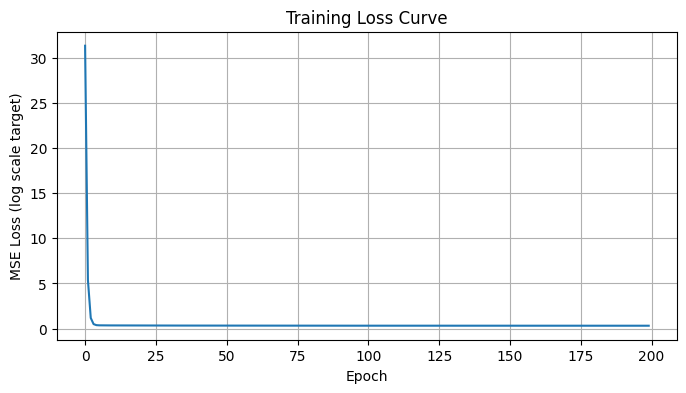

In [101]:
# 6.3 Training Loss Curve (MSE trên sales_amount_log)

plt.figure(figsize=(8, 4))
plt.plot(model.loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (log scale target)")
plt.grid(True)
plt.show()


### 6.4. Actual vs Predicted (doanh số gốc)


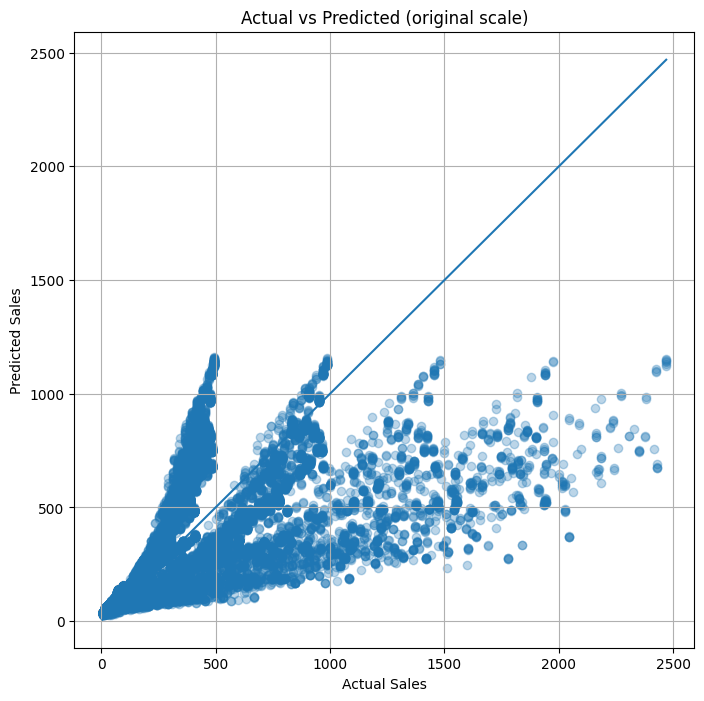

In [102]:
# 6.4 Actual vs Predicted (original scale)

plt.figure(figsize=(8, 8))
plt.scatter(y_test_orig, predictions, alpha=0.3)
plt.plot(
    [y_test_orig.min(), y_test_orig.max()],
    [y_test_orig.min(), y_test_orig.max()],
)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted (original scale)")
plt.grid(True)
plt.show()


### 6.5. Residual plot (doanh số gốc)


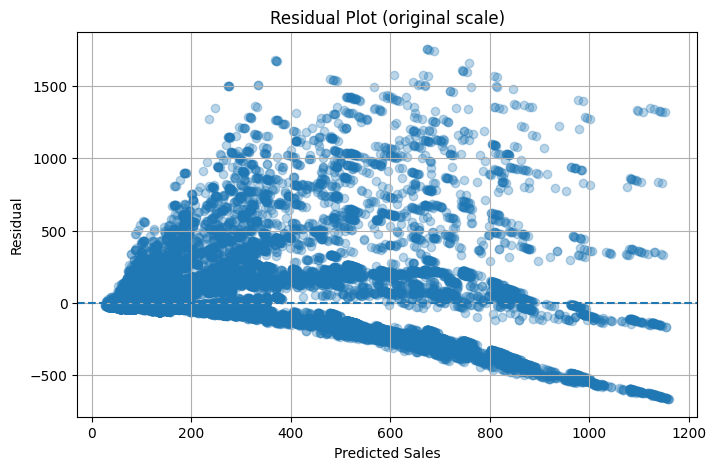

In [103]:
# 6.5 Residual Plot (original scale)

residuals = y_test_orig - predictions

plt.figure(figsize=(8, 5))
plt.scatter(predictions, residuals, alpha=0.3)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual")
plt.title("Residual Plot (original scale)")
plt.grid(True)
plt.show()
